# Unziping Dataset

In [1]:
from zipfile import ZipFile  
file_name = "../input/data-science-bowl-2018/stage1_train.zip" 
with ZipFile(file_name, 'r') as zip: 
    print('Extracting the files') 
    zip.extractall("stage1_train") 
    print('Done!')

Extracting the files
Done!


# Downloading and Importing all necessary libraries

In [2]:
# Modern Kaggle environments already have a highly optimized version of Albumentations pre-installed.
# We only install it if it is not already present, ensuring full compatibility without breaking pre-installed SciPy/NumPy.
try:
    import albumentations
    print(f"Albumentations is already installed: {albumentations.__version__}")
except ImportError:
    print("Albumentations not found. Installing...")
    # Install modern albumentations using python subprocess to prevent NumPy 2.0 / SciPy incompatibilities
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "albumentations"])

Albumentations is already installed: 2.0.8


In [3]:
# To check whether the installation is successfull or not
import albumentations
albumentations.__version__

'2.0.8'

In [4]:
import os
import time
import copy
from collections import defaultdict
import torch
import shutil
import pandas as pd
from skimage import io, transform
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, utils
from torch import nn
import albumentations as A
try:
    from albumentations.pytorch import ToTensorV2 as ToTensor
except ImportError:
    from albumentations.pytorch import ToTensor
#import tqdm as tqdm
from tqdm import tqdm as tqdm

from albumentations import (HorizontalFlip, ShiftScaleRotate, Normalize, Resize, Compose, GaussNoise)
import cv2

from torch.autograd import Variable
from torch.nn import Linear, ReLU, CrossEntropyLoss, Sequential, Conv2d, MaxPool2d, Module, Softmax, BatchNorm2d, Dropout
from torch.optim import Adam, SGD
import torch.nn.functional as F
from PIL import Image
from torch import nn
import zipfile

import random

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [5]:
TRAIN_PATH = 'stage1_train/'

In [6]:
lenData = len(os.listdir(TRAIN_PATH))
print("Total Number of Images: {}".format(lenData))

Total Number of Images: 670


# Data Pipeline

In [7]:
#Albumentation
def get_train_transform():
   return A.Compose(
       [
        A.Resize(256, 256),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        A.HorizontalFlip(p=0.25),
        A.VerticalFlip(p=0.25),
        ToTensor()
        ])
   
#Dataset Loader
class LoadDataSet(Dataset):
        def __init__(self,path, transform=None):
            self.path = path
            self.folders = os.listdir(path)
            self.transforms = get_train_transform()
        
        def __len__(self):
            return len(self.folders)
              
        def __getitem__(self,idx):
            image_folder = os.path.join(self.path,self.folders[idx],'images/')
            mask_folder = os.path.join(self.path,self.folders[idx],'masks/')
            image_path = os.path.join(image_folder,os.listdir(image_folder)[0])
            
            img = io.imread(image_path)[:,:,:3].astype('float32')
            img = transform.resize(img,(128,128))
            
            mask = self.get_mask(mask_folder, 128, 128 ).astype('float32')

            augmented = self.transforms(image=img, mask=mask)
            img = augmented['image']
            mask = augmented['mask']
            
            # Robust, universal tensor-shaping logic for both old and new albumentations
            if not isinstance(img, torch.Tensor):
                img = torch.from_numpy(img).permute(2, 0, 1)
            if not isinstance(mask, torch.Tensor):
                mask = torch.from_numpy(mask).permute(2, 0, 1)
                
            # Keep mask shape consistent as [1, H, W] for all albumentations versions
            if len(mask.shape) == 3:
                if mask.shape[0] != 1 and mask.shape[2] == 1:
                    mask = mask.permute(2, 0, 1)
            elif len(mask.shape) == 4: # Old albumentations [1, H, W, 1] format
                mask = mask[0].permute(2, 0, 1)
            elif len(mask.shape) == 2:
                mask = mask.unsqueeze(0)
                
            return (img, mask) 

        def get_mask(self,mask_folder,IMG_HEIGHT, IMG_WIDTH):
            mask = np.zeros((IMG_HEIGHT, IMG_WIDTH, 1), dtype=bool)
            for mask_ in os.listdir(mask_folder):
                    mask_ = io.imread(os.path.join(mask_folder,mask_))
                    mask_ = transform.resize(mask_, (IMG_HEIGHT, IMG_WIDTH))
                    mask_ = np.expand_dims(mask_,axis=-1)
                    mask = np.maximum(mask, mask_)
              
            return mask

In [8]:
train_dataset = LoadDataSet(TRAIN_PATH, transform=get_train_transform())

In [9]:
#Print the shape of image and mask
image, mask = train_dataset.__getitem__(0)
print(image.shape)
print(mask.shape)

torch.Size([3, 256, 256])
torch.Size([1, 256, 256])


In [10]:
train_dataset.__len__()

670

In [11]:
image

tensor([[[-2.0993, -2.0992, -2.0991,  ..., -1.9998, -1.9888, -1.9833],
         [-2.0972, -2.0976, -2.0984,  ..., -2.0066, -1.9954, -1.9898],
         [-2.0930, -2.0943, -2.0969,  ..., -2.0202, -2.0086, -2.0028],
         ...,
         [-2.0871, -2.0844, -2.0790,  ..., -1.7112, -1.7165, -1.7192],
         [-2.0867, -2.0834, -2.0768,  ..., -1.7730, -1.8095, -1.8278],
         [-2.0865, -2.0829, -2.0757,  ..., -1.8039, -1.8561, -1.8822]],

        [[-2.0167, -2.0166, -2.0165,  ..., -1.9150, -1.9038, -1.8982],
         [-2.0145, -2.0149, -2.0158,  ..., -1.9219, -1.9105, -1.9048],
         [-2.0103, -2.0116, -2.0143,  ..., -1.9358, -1.9239, -1.9180],
         ...,
         [-2.0043, -2.0015, -1.9959,  ..., -1.6199, -1.6254, -1.6281],
         [-2.0038, -2.0005, -1.9937,  ..., -1.6831, -1.7205, -1.7392],
         [-2.0036, -2.0000, -1.9926,  ..., -1.7147, -1.7680, -1.7947]],

        [[-1.7855, -1.7854, -1.7854,  ..., -1.6842, -1.6731, -1.6675],
         [-1.7834, -1.7838, -1.7846,  ..., -1

In [12]:
mask

tensor([[[0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
          0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
          0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
          0.0000e+00, 0.0000e+00],
         ...,
         [0.0000e+00, 0.0000e+00, 8.7312e-04,  ..., 1.0000e+00,
          1.0000e+00, 1.0000e+00],
         [0.0000e+00, 0.0000e+00, 1.1313e-03,  ..., 1.0000e+00,
          1.0000e+00, 1.0000e+00],
         [0.0000e+00, 0.0000e+00, 1.1313e-03,  ..., 1.0000e+00,
          1.0000e+00, 1.0000e+00]]])

In [13]:
def format_image(img):
    """
    Function to de-standardize the image
    arg: Input Image
    returns: De-standardized image
    """
    img = np.array(np.transpose(img, (1,2,0)))
    mean = np.array((0.485, 0.456, 0.406))
    std = np.array((0.229, 0.224, 0.225))
    img  = std * img + mean
    img = img*255
    img = img.astype(np.uint8)
    return img

def format_mask(mask):
    """
    Function to reshape the mask
    """
    mask = np.squeeze(np.transpose(mask, (1,2,0)))
    return mask

In [14]:
def visualize_dataset(n_images, predict=None):
  """
  Function to visualize images and masks
  """
  maxRange = train_dataset.__len__()
  images = random.sample(range(0, maxRange), n_images)
  figure, ax = plt.subplots(nrows=len(images), ncols=2, figsize=(5, 8))
  print(images)
  for i in range(0, len(images)):
    img_no = images[i]
    image, mask = train_dataset.__getitem__(img_no)
    image = format_image(image)
    mask = format_mask(mask)
    ax[i, 0].imshow(image)
    ax[i, 1].imshow(mask, interpolation="nearest", cmap="gray")
    ax[i, 0].set_title("Ground Truth Image")
    ax[i, 1].set_title("Mask")
    ax[i, 0].set_axis_off()
    ax[i, 1].set_axis_off()
  plt.tight_layout()
  plt.show()

[267, 552, 486]


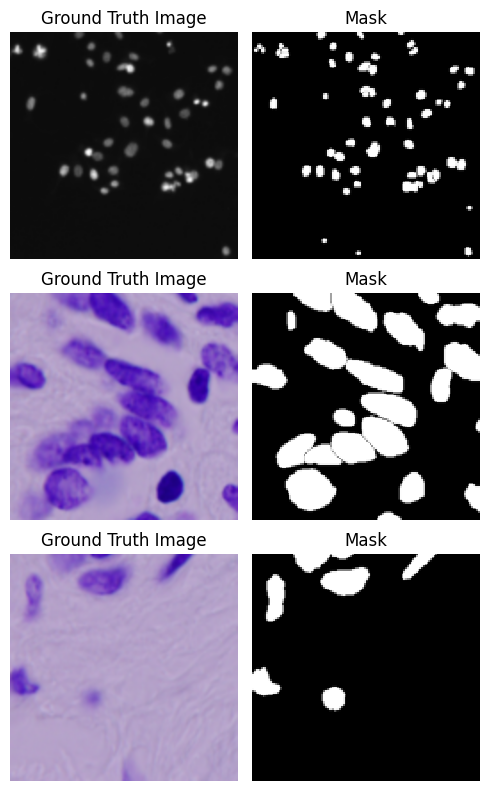

In [15]:
visualize_dataset(3)

In [16]:
## Split train and validation set.
train_data, valid_data = random_split(train_dataset, [469, 201])

train_loader = DataLoader(dataset=train_data, batch_size=10, shuffle=True)

val_loader = DataLoader(dataset=valid_data, batch_size=10)

# Defining Model - Unet with residual encoders

In [17]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
            
    def forward(self, x):
        residual = self.shortcut(x)
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += residual
        out = self.relu(out)
        return out

class DecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DecoderBlock, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        
    def forward(self, x):
        return self.conv(x)

class AttentionBlock(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super(AttentionBlock, self).__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)
        
    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi

class UNetPlusPlus(nn.Module):
    def __init__(self, in_channels=3, filters=[32, 64, 128, 256, 512]):
        super(UNetPlusPlus, self).__init__()
        
        self.filters = filters
        
        # Encoder (ResNet-style, built from scratch and fully trainable)
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, filters[0], kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(filters[0]),
            nn.ReLU(inplace=True),
            ResidualBlock(filters[0], filters[0], stride=1)
        )
        
        self.enc1 = nn.Sequential(
            ResidualBlock(filters[0], filters[1], stride=2),
            ResidualBlock(filters[1], filters[1], stride=1)
        )
        self.enc2 = nn.Sequential(
            ResidualBlock(filters[1], filters[2], stride=2),
            ResidualBlock(filters[2], filters[2], stride=1)
        )
        self.enc3 = nn.Sequential(
            ResidualBlock(filters[2], filters[3], stride=2),
            ResidualBlock(filters[3], filters[3], stride=1)
        )
        self.enc4 = nn.Sequential(
            ResidualBlock(filters[3], filters[4], stride=2),
            ResidualBlock(filters[4], filters[4], stride=1)
        )
        
        # Bilinear upsampling for spatial consistency and memory efficiency
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        
        # UNet++ Decoder Blocks (nested/dense skip pathways) with Attention
        # j = 1
        self.ag0_1 = AttentionBlock(F_g=filters[1], F_l=filters[0], F_int=filters[0]//2)
        self.db0_1 = DecoderBlock(filters[0] + filters[1], filters[0])
        self.ag1_1 = AttentionBlock(F_g=filters[2], F_l=filters[1], F_int=filters[1]//2)
        self.db1_1 = DecoderBlock(filters[1] + filters[2], filters[1])
        self.ag2_1 = AttentionBlock(F_g=filters[3], F_l=filters[2], F_int=filters[2]//2)
        self.db2_1 = DecoderBlock(filters[2] + filters[3], filters[2])
        self.ag3_1 = AttentionBlock(F_g=filters[4], F_l=filters[3], F_int=filters[3]//2)
        self.db3_1 = DecoderBlock(filters[3] + filters[4], filters[3])
        
        # j = 2
        self.ag0_2 = AttentionBlock(F_g=filters[1], F_l=filters[0]*2, F_int=filters[0]//2)
        self.db0_2 = DecoderBlock(filters[0]*2 + filters[1], filters[0])
        self.ag1_2 = AttentionBlock(F_g=filters[2], F_l=filters[1]*2, F_int=filters[1]//2)
        self.db1_2 = DecoderBlock(filters[1]*2 + filters[2], filters[1])
        self.ag2_2 = AttentionBlock(F_g=filters[3], F_l=filters[2]*2, F_int=filters[2]//2)
        self.db2_2 = DecoderBlock(filters[2]*2 + filters[3], filters[2])
        
        # j = 3
        self.ag0_3 = AttentionBlock(F_g=filters[1], F_l=filters[0]*3, F_int=filters[0]//2)
        self.db0_3 = DecoderBlock(filters[0]*3 + filters[1], filters[0])
        self.ag1_3 = AttentionBlock(F_g=filters[2], F_l=filters[1]*3, F_int=filters[1]//2)
        self.db1_3 = DecoderBlock(filters[1]*3 + filters[2], filters[1])
        
        # j = 4
        self.ag0_4 = AttentionBlock(F_g=filters[1], F_l=filters[0]*4, F_int=filters[0]//2)
        self.db0_4 = DecoderBlock(filters[0]*4 + filters[1], filters[0])
        
        # Final output conv (returns logits, no sigmoid)
        self.final = nn.Conv2d(filters[0], 1, kernel_size=1)
        
    def forward(self, x):
        # Encoder backbone
        x0_0 = self.stem(x)
        x1_0 = self.enc1(x0_0)
        x2_0 = self.enc2(x1_0)
        x3_0 = self.enc3(x2_0)
        x4_0 = self.enc4(x3_0)
        
        # Column j = 1
        g3_1 = self.up(x4_0)
        att3_1 = self.ag3_1(g3_1, x3_0)
        x3_1 = self.db3_1(torch.cat([att3_1, g3_1], dim=1))
        
        g2_1 = self.up(x3_0)
        att2_1 = self.ag2_1(g2_1, x2_0)
        x2_1 = self.db2_1(torch.cat([att2_1, g2_1], dim=1))
        
        g1_1 = self.up(x2_0)
        att1_1 = self.ag1_1(g1_1, x1_0)
        x1_1 = self.db1_1(torch.cat([att1_1, g1_1], dim=1))
        
        g0_1 = self.up(x1_0)
        att0_1 = self.ag0_1(g0_1, x0_0)
        x0_1 = self.db0_1(torch.cat([att0_1, g0_1], dim=1))
        
        # Column j = 2
        g2_2 = self.up(x3_1)
        skips2_2 = torch.cat([x2_0, x2_1], dim=1)
        att2_2 = self.ag2_2(g2_2, skips2_2)
        x2_2 = self.db2_2(torch.cat([att2_2, g2_2], dim=1))
        
        g1_2 = self.up(x2_1)
        skips1_2 = torch.cat([x1_0, x1_1], dim=1)
        att1_2 = self.ag1_2(g1_2, skips1_2)
        x1_2 = self.db1_2(torch.cat([att1_2, g1_2], dim=1))
        
        g0_2 = self.up(x1_1)
        skips0_2 = torch.cat([x0_0, x0_1], dim=1)
        att0_2 = self.ag0_2(g0_2, skips0_2)
        x0_2 = self.db0_2(torch.cat([att0_2, g0_2], dim=1))
        
        # Column j = 3
        g1_3 = self.up(x2_2)
        skips1_3 = torch.cat([x1_0, x1_1, x1_2], dim=1)
        att1_3 = self.ag1_3(g1_3, skips1_3)
        x1_3 = self.db1_3(torch.cat([att1_3, g1_3], dim=1))
        
        g0_3 = self.up(x1_2)
        skips0_3 = torch.cat([x0_0, x0_1, x0_2], dim=1)
        att0_3 = self.ag0_3(g0_3, skips0_3)
        x0_3 = self.db0_3(torch.cat([att0_3, g0_3], dim=1))
        
        # Column j = 4
        g0_4 = self.up(x1_3)
        skips0_4 = torch.cat([x0_0, x0_1, x0_2, x0_3], dim=1)
        att0_4 = self.ag0_4(g0_4, skips0_4)
        x0_4 = self.db0_4(torch.cat([att0_4, g0_4], dim=1))
        
        return self.final(x0_4)


## Defining Loss function

In [18]:
class BCEDiceLoss(nn.Module):
    def __init__(self, alpha=1.0, beta=1.0):
        super(BCEDiceLoss, self).__init__()
        self.alpha = alpha
        self.beta = beta
        self.bce = nn.BCEWithLogitsLoss()
        
    def forward(self, inputs, targets, smooth=1):
        bce_loss = self.bce(inputs, targets)
        
        # Compute Dice loss (applying sigmoid on raw logits)
        probs = torch.sigmoid(inputs)
        probs = probs.view(-1)
        targets = targets.view(-1)
        
        intersection = (probs * targets).sum()
        dice = (2. * intersection + smooth) / (probs.sum() + targets.sum() + smooth)
        dice_loss = 1 - dice
        
        return self.alpha * dice_loss + self.beta * bce_loss

class DiceLoss(nn.Module):
    def __init__(self, weight=None, size_average=True):
        super(DiceLoss, self).__init__()

    def forward(self, inputs, targets, smooth=1):
        # Apply sigmoid since model outputs raw logits
        inputs = torch.sigmoid(inputs)
        
        inputs = inputs.view(-1)
        targets = targets.view(-1)
        
        intersection = (inputs * targets).sum()                            
        dice = (2.*intersection + smooth)/(inputs.sum() + targets.sum() + smooth)  
        
        return 1 - dice

class IoU(nn.Module):
    def __init__(self, weight=None, size_average=True):
        super(IoU, self).__init__()

    def forward(self, inputs, targets, smooth=1):
        # Apply sigmoid since model outputs raw logits
        inputs = torch.sigmoid(inputs)
        
        inputs = inputs.view(-1)
        targets = targets.view(-1)
        
        intersection = (inputs * targets).sum()
        total = (inputs + targets).sum()
        union = total - intersection 
        
        iou_val = (intersection + smooth)/(union + smooth)
                
        return iou_val

In [19]:
# Instantiate custom UNetPlusPlus with fully trainable, ResNet-style encoder from scratch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNetPlusPlus(in_channels=3).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


In [20]:
def save_ckp(state, is_best, checkpoint_path, best_model_path):
    """
    state: checkpoint we want to save
    is_best: is this the best checkpoint; min validation loss
    checkpoint_path: path to save checkpoint
    best_model_path: path to save best model
    """
    f_path = checkpoint_path
    # save checkpoint data to the path given, checkpoint_path
    torch.save(state, f_path)
    # if it is a best model, min validation loss
    if is_best:
        best_fpath = best_model_path
        # copy that checkpoint file to best path given, best_model_path
        shutil.copyfile(f_path, best_fpath)

def load_ckp(checkpoint_fpath, model, optimizer):
    """
    checkpoint_path: path to save checkpoint
    model: model that we want to load checkpoint parameters into       
    optimizer: optimizer we defined in previous training
    """
    # load check point
    checkpoint = torch.load(checkpoint_fpath)
    # initialize state_dict from checkpoint to model
    model.load_state_dict(checkpoint['state_dict'])
    # initialize optimizer from checkpoint to optimizer
    optimizer.load_state_dict(checkpoint['optimizer'])
    # initialize valid_loss_min from checkpoint to valid_loss_min
    valid_loss_min = checkpoint['valid_loss_min']
    # return model, optimizer, epoch value, min validation loss 
    return model, optimizer, checkpoint['epoch'], valid_loss_min.item()

In [21]:
# Creating model weight directory
weight_path = "model_weight"
if not os.path.exists(weight_path):
    os.makedirs(weight_path)

# Model Training

In [22]:
# The combined BCE + Dice loss as final training criterion
criterion = BCEDiceLoss(alpha=1.0, beta=1.0)
accuracy_metric = IoU()
num_epochs=40
valid_loss_min = np.inf

checkpoint_path = 'model_weight/chkpoint_'
best_model_path = 'model_weight/bestmodel.pt'

total_train_loss = []
total_train_score = []
total_valid_loss = []
total_valid_score = []

losses_value = 0
for epoch in range(num_epochs):
  
    train_loss = []
    train_score = []
    valid_loss = []
    valid_score = []
    #<-----------Training Loop---------------------------->
    pbar = tqdm(train_loader, desc = 'description')
    for x_train, y_train in pbar:
      # Use .to(device) and cast to float32 explicitly, avoiding deprecated Variable
      x_train = x_train.to(device, dtype=torch.float32)
      y_train = y_train.to(device, dtype=torch.float32)
      
      optimizer.zero_grad()
      output = model(x_train)
      
      # Loss calculation expects logits
      loss = criterion(output, y_train)
      losses_value = loss.item()
      
      # Score calculation internally applies sigmoid
      score = accuracy_metric(output, y_train)
      
      loss.backward()
      optimizer.step()
      
      train_loss.append(losses_value)
      train_score.append(score.item())
      pbar.set_description(f"Epoch: {epoch+1}, loss: {losses_value:.4f}, IoU: {score.item():.4f}")

    #<---------------Validation Loop---------------------->
    with torch.no_grad():
      for image, mask in val_loader:
        # Also use explicit device casting here
        image = image.to(device, dtype=torch.float32)
        mask = mask.to(device, dtype=torch.float32)
        
        output = model(image)
        ## Compute Loss Value
        loss = criterion(output, mask)
        losses_value = loss.item()
        ## Compute Accuracy Score
        score = accuracy_metric(output, mask)
        
        valid_loss.append(losses_value)
        valid_score.append(score.item())

    total_train_loss.append(np.mean(train_loss))
    total_train_score.append(np.mean(train_score))
    total_valid_loss.append(np.mean(valid_loss))
    total_valid_score.append(np.mean(valid_score))
    print(f"\n###############Train Loss: {total_train_loss[-1]:.6f}, Train IOU: {total_train_score[-1]:.6f}###############")
    print(f"###############Valid Loss: {total_valid_loss[-1]:.6f}, Valid IOU: {total_valid_score[-1]:.6f}###############")

    # Save best model Checkpoint
    checkpoint = {
        'epoch': epoch + 1,
        'valid_loss_min': total_valid_loss[-1],
        'state_dict': model.state_dict(),
        'optimizer': optimizer.state_dict(),
    }
    
    save_ckp(checkpoint, False, checkpoint_path, best_model_path)
    
    if total_valid_loss[-1] <= valid_loss_min:
        print('Validation loss decreased ({:.6f} --> {:.6f}).  Saving model ...'.format(valid_loss_min, total_valid_loss[-1]))
        save_ckp(checkpoint, True, checkpoint_path, best_model_path)
        valid_loss_min = total_valid_loss[-1]


Epoch: 1, loss: 0.7552, IoU: 0.3421: 100%|██████████| 47/47 [03:10<00:00,  4.06s/it]



###############Train Loss: 1.035934, Train IOU: 0.233138###############
###############Valid Loss: 0.844416, Valid IOU: 0.298142###############
Validation loss decreased (inf --> 0.844416).  Saving model ...


Epoch: 2, loss: 0.5395, IoU: 0.5235: 100%|██████████| 47/47 [03:12<00:00,  4.10s/it]



###############Train Loss: 0.721501, Train IOU: 0.364793###############
###############Valid Loss: 0.622745, Valid IOU: 0.418322###############
Validation loss decreased (0.844416 --> 0.622745).  Saving model ...


Epoch: 3, loss: 0.5362, IoU: 0.4688: 100%|██████████| 47/47 [03:12<00:00,  4.10s/it]


...


###############Train Loss: 0.243664, Train IOU: 0.743712###############
###############Valid Loss: 0.250245, Valid IOU: 0.735485###############
Validation loss decreased (0.252228 --> 0.250245).  Saving model ...


Epoch: 39, loss: 0.2612, IoU: 0.7011: 100%|██████████| 47/47 [03:11<00:00,  4.08s/it]



###############Train Loss: 0.240562, Train IOU: 0.745882###############
###############Valid Loss: 0.260507, Valid IOU: 0.729236###############


Epoch: 40, loss: 0.1947, IoU: 0.7914: 100%|██████████| 47/47 [03:11<00:00,  4.08s/it]



###############Train Loss: 0.247098, Train IOU: 0.741428###############
###############Valid Loss: 0.249034, Valid IOU: 0.738768###############
Validation loss decreased (0.250245 --> 0.249034).  Saving model ...


# Validating the model

In [23]:
# Loading the model from a specified path or fallback to the recently trained model
import os
import torch

# Specify the path to a trained model file (e.g., custom weights or checkpoint file)
# Change this variable to your desired weights path to validate/visualize a pre-trained model without retraining.
custom_model_path = None  # e.g., 'model_weight/bestmodel.pt'

# Determine target path: fallback to best_model_path or checkpoint_path if custom path is not set/found
target_load_path = custom_model_path if (custom_model_path and os.path.exists(custom_model_path)) else (best_model_path if os.path.exists(best_model_path) else checkpoint_path)

if os.path.exists(target_load_path):
    print(f"Loading model weights from: {target_load_path}")
    try:
        # Try loading as a full checkpoint first
        model, optimizer, start_epoch, valid_loss_min = load_ckp(target_load_path, model, optimizer)
        print("Successfully loaded full checkpoint with optimizer state.")
    except Exception as e:
        # Fallback to loading as a raw state dict if full checkpoint keys are missing
        print(f"Could not load as full checkpoint ({e}). Trying to load as raw state dict...")
        checkpoint = torch.load(target_load_path, weights_only= False)
        if isinstance(checkpoint, dict) and 'state_dict' in checkpoint:
            model.load_state_dict(checkpoint['state_dict'])
        else:
            model.load_state_dict(checkpoint)
        print("Successfully loaded model state dict.")
else:
    print(f"Warning: No trained model weights found at {target_load_path}. Proceeding with current model state.")

Loading model weights from: model_weight/bestmodel.pt
Could not load as full checkpoint (Weights only load failed. This file can still be loaded, to do so you have two options, do those steps only if you trust the source of the checkpoint. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray.scalar])` or the `torch.serialization.safe_globals([numpy._core.multiarray.scalar])` context manager to allowlist this global if you trust this 

In [24]:
def visualize_predict(model, n_images):
  # Set model to evaluation mode
  model = model.eval()
  figure, ax = plt.subplots(nrows=n_images, ncols=3, figsize=(15, 18))
  with torch.no_grad():
    for data, mask in val_loader:
        data = data.cuda()
        mask = mask.cuda()
        # Apply sigmoid since model outputs raw logits
        o = torch.sigmoid(model(data))
        break
  for img_no in range(0, n_images):
    tm = o[img_no][0].data.cpu().numpy()
    img = data[img_no].data.cpu()
    msk = mask[img_no].data.cpu()
    img = format_image(img)
    msk = format_mask(msk)
    ax[img_no, 0].imshow(img)
    ax[img_no, 1].imshow(msk, interpolation="nearest", cmap="gray")
    ax[img_no, 2].imshow(tm, interpolation="nearest", cmap="gray")
    ax[img_no, 0].set_title("Ground Truth Image")
    ax[img_no, 1].set_title("Ground Truth Mask")
    ax[img_no, 2].set_title("Predicted Mask")
    ax[img_no, 0].set_axis_off()
    ax[img_no, 1].set_axis_off()
    ax[img_no, 2].set_axis_off()
  plt.tight_layout()
  plt.show()

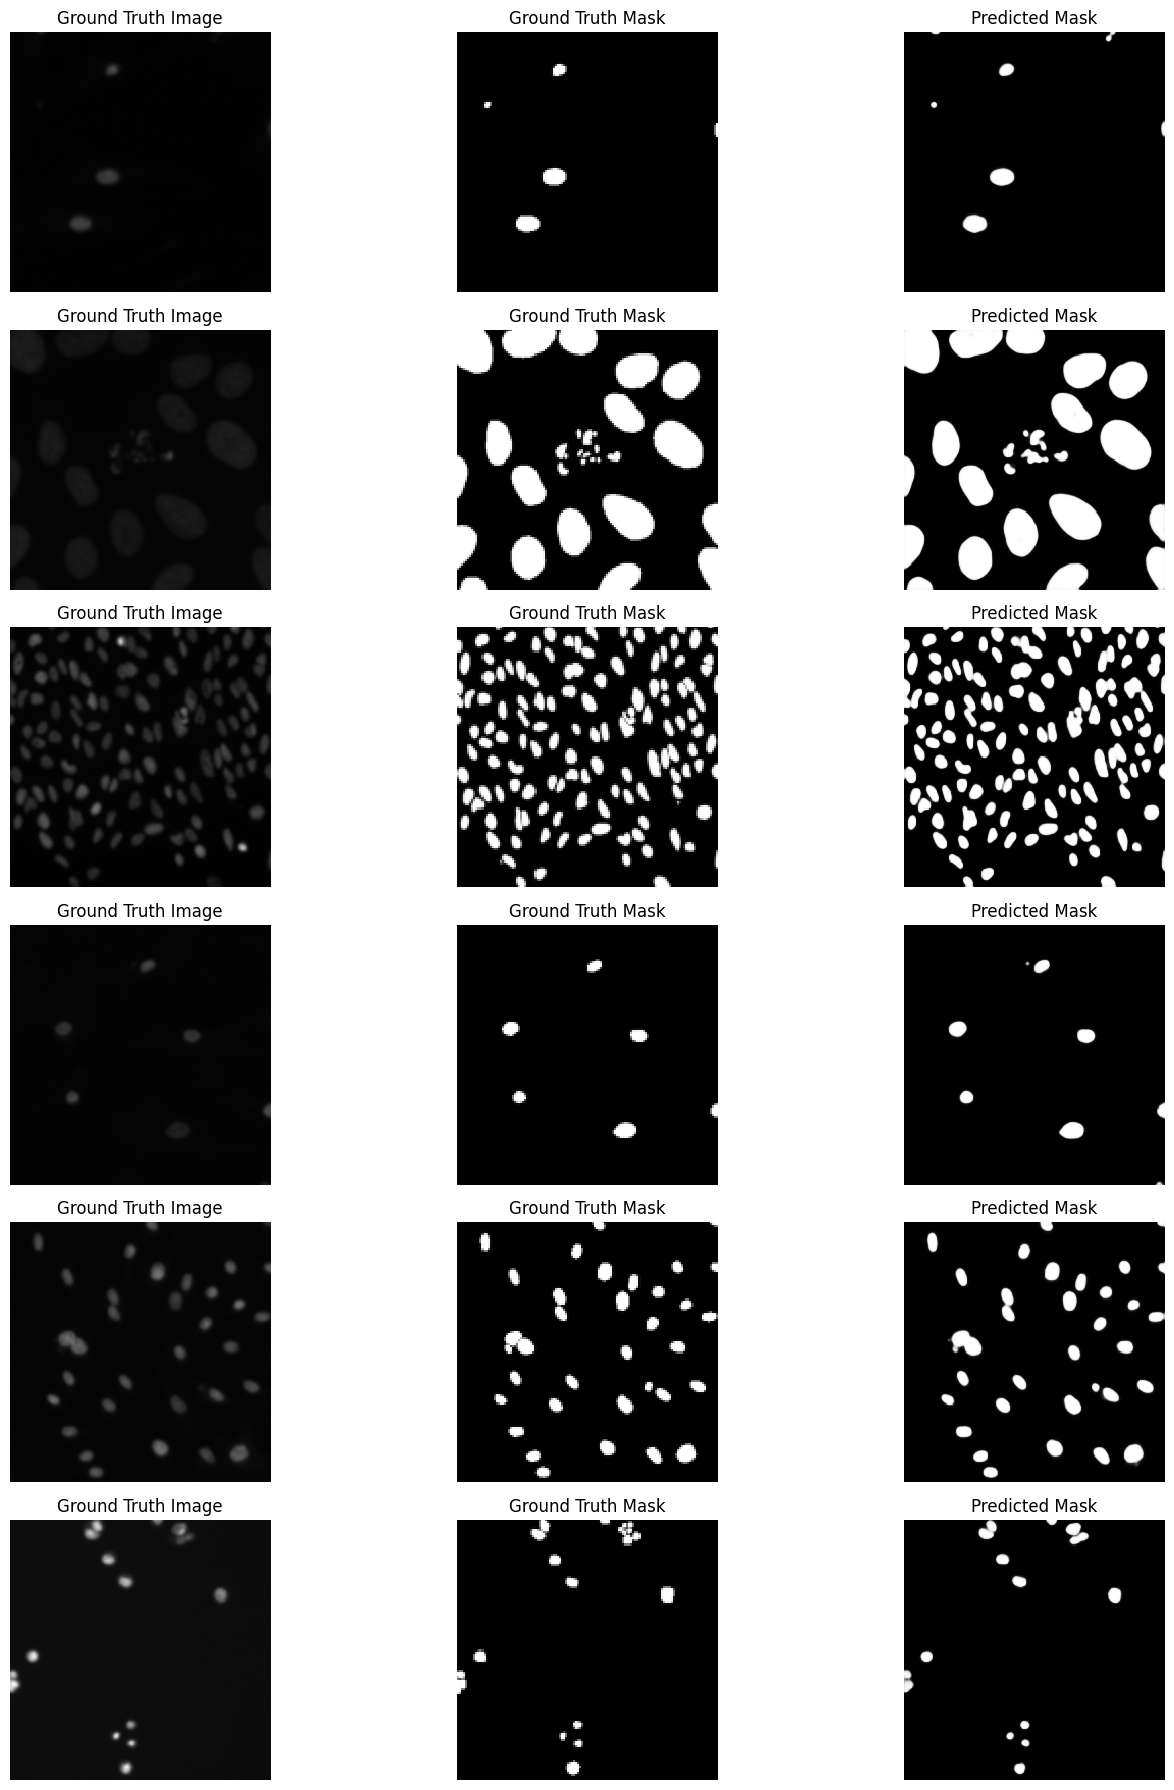

In [25]:
visualize_predict(model, 6)

## Visualization

<Figure size 640x480 with 0 Axes>

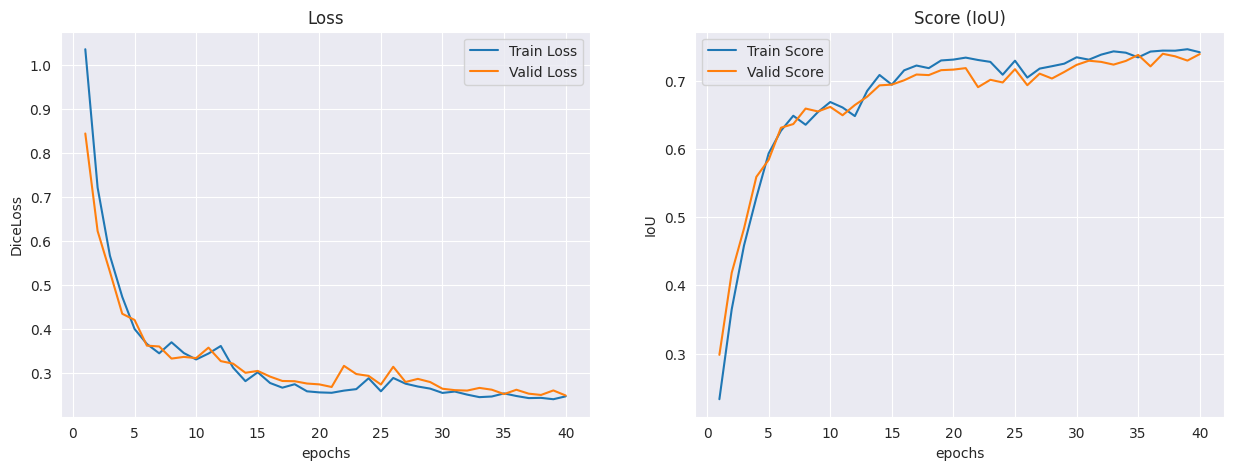

In [26]:
import seaborn as sns

plt.figure(1)
plt.figure(figsize=(15,5))
sns.set_style(style="darkgrid")
plt.subplot(1, 2, 1)
sns.lineplot(x=range(1, len(total_train_loss) + 1), y=total_train_loss, label="Train Loss")
sns.lineplot(x=range(1, len(total_train_loss) + 1), y=total_valid_loss, label="Valid Loss")
plt.title("Loss")
plt.xlabel("epochs")
plt.ylabel("DiceLoss")

plt.subplot(1, 2, 2)
sns.lineplot(x=range(1, len(total_train_loss) + 1), y=total_train_score, label="Train Score")
sns.lineplot(x=range(1, len(total_train_loss) + 1), y=total_valid_score, label="Valid Score")
plt.title("Score (IoU)")
plt.xlabel("epochs")
plt.ylabel("IoU")
plt.show()

# Model Evaluation Summary

In [27]:
# Full Summary of Scores and Metrics on the Dataset
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm

# Automatically use test_loader if defined in the notebook, otherwise fallback to val_loader
eval_loader = test_loader if 'test_loader' in globals() else val_loader
eval_name = "Test Set" if 'test_loader' in globals() else "Validation Set"

print(f"Running evaluation on {eval_name}...")

model.eval()
all_losses = []
all_scores = []

with torch.no_grad():
    for images, masks in tqdm(eval_loader, desc="Evaluating"):
        images = images.cuda()
        masks = masks.cuda()
        
        # Forward pass
        outputs = model(images)
        
        # Calculate loss
        loss = criterion(outputs, masks)
        all_losses.append(loss.item())
        
        # Calculate score (IoU)
        score = accuracy_metric(outputs, masks)
        all_scores.append(score.item())

# Calculate summary statistics
summary_stats = {
    "Metric": ["Dice Loss", "IoU Score (Accuracy)"],
    "Mean": [np.mean(all_losses), np.mean(all_scores)],
    "Standard Deviation": [np.std(all_losses), np.std(all_scores)],
    "Minimum": [np.min(all_losses), np.min(all_scores)],
    "Maximum": [np.max(all_losses), np.max(all_scores)]
}

# Display as a formatted Pandas DataFrame
df_summary = pd.DataFrame(summary_stats)
print("\n" + "="*60)
print(f"                EVALUATION SUMMARY ({eval_name})")
print("="*60)
display(df_summary)
print("="*60)

Running evaluation on Validation Set...


Evaluating: 100%|██████████| 21/21 [01:27<00:00,  4.18s/it]


                EVALUATION SUMMARY (Validation Set)


,Metric,Mean,Standard Deviation,Minimum,Maximum
0,Dice Loss,0.247894,0.053217,0.155534,0.357768
1,IoU Score (Accuracy),0.744386,0.039282,0.661286,0.806082


Metric	      Mean      Std dev.	Minimum	    Maximum
Dice Loss	0.247894	0.053217	0.155534	0.357768
IoU Score   0.744386	0.039282	0.661286	0.806082